In [3]:
import os
import sys

paths = [
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/myopacus",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/torchdp",
    "/your/path/rpdp_fl/experiments",
]

for p in paths:
    if p not in sys.path:
        sys.path.append(p)

# Optional: also update environment variable
os.environ["PYTHONPATH"] = ":".join(sys.path)

In [8]:
from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "heart_disease"   # change to "fashion_mnist" when needed

all_results = []

 #"iid_10",
 #"niid_dir_5"

# "niid_10_2",
# "niid_dir_1",
# "niid_dir_5"
 
data_types = [
    "niid_10_5"

]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_dp_unidp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))

Loading: ./fed_heart_disease/niid_10_5/ditto/niid_10_5_results_ditto_dp_unidp_heart_disease.csv


This graphs plots comparing Vanilla, Ditto w Global DP, and Ditto w Local DP
for one value of lambda and num_personal_steps

[15, 30]


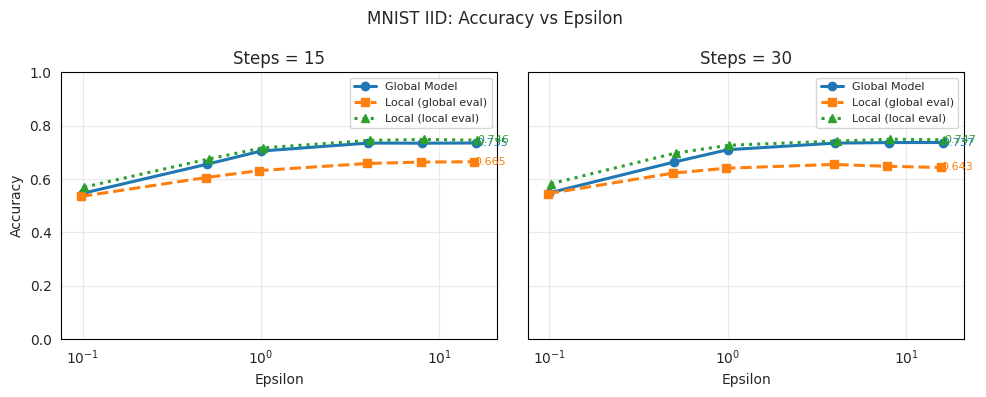

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor':'black'})
#'MNIST IID'
dataset_names = ['MNIST IID' ,'MNIST NIID-5', 'MNIST NIID-2', 'MNIST Dirch-1', 'MNIST Dirch-5']
methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Local (global eval)',
    'personal': 'Local (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.98,
    'personal': 1.02
}

NUM_STEPS_LIST = sorted(all_results[0]['num_personal_steps'].unique())
print(NUM_STEPS_LIST)

# ========================
# FIGURE: datasets × steps
# ========================
for d_idx, df in enumerate(all_results):

    df['e'] = df['e'].astype(float)

    n_steps = len(NUM_STEPS_LIST)
    fig, axs = plt.subplots(1, n_steps, figsize=(5 * n_steps, 4), sharey=True)

    if n_steps == 1:
        axs = [axs]

    for s_idx, steps in enumerate(NUM_STEPS_LIST):

        ax = axs[s_idx]

        df_s = df[df['num_personal_steps'] == steps]

        # average across seeds (if any)
        df_grouped = (
            df_s.groupby(['e', 'type'])['mean_perf']
            .mean()
            .reset_index()
        )

        for method in methods:

            df_m = df_grouped[df_grouped['type'] == method]

            if len(df_m) == 0:
                continue

            df_m = df_m.sort_values('e')

            x = df_m['e'].values * offset_map[method]

            ax.plot(
                x,
                df_m['mean_perf'],
                label=method_labels[method],
                linestyle=linestyle_map[method],
                marker=marker_map[method],
                color=colors[method],
                linewidth=2.2
            )
            # ========================
            # label last point
            # ========================
            x_last = x[-1]
            y_last = df_m['mean_perf'].values[-1]

            x_last = x[-1]
            y_last = df_m['mean_perf'].values[-1]

            ax.text(
                x_last,
                y_last,
                f"{y_last:.3f}",   # or .4f if you want more precision
                fontsize=8,
                color=colors[method],
                ha='left',
                va='center'
            )

        ax.set_xscale('log')
        ax.set_title(f"Steps = {steps}")
        ax.set_xlabel("Epsilon")

        if s_idx == 0:
            ax.set_ylabel("Accuracy")

        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.4)

        ax.legend(fontsize=8)

    fig.suptitle(f"{dataset_names[d_idx]}: Accuracy vs Epsilon", fontsize=12)
    plt.tight_layout()
    plt.show()

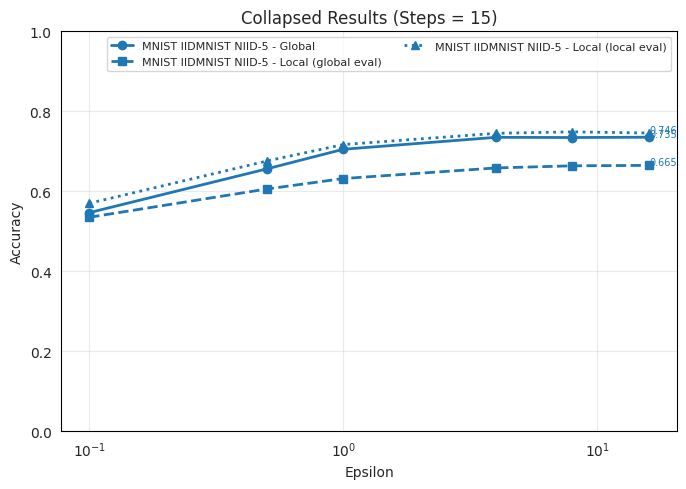

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor':'black'})

dataset_names = ['MNIST IID' 'MNIST NIID-5', 'MNIST NIID-2', 'MNIST Dirch-1', 'MNIST Dirch-5']
methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global',
    'pooled': 'Local (global eval)',
    'personal': 'Local (local eval)'
}

colors = sns.color_palette("tab10", len(dataset_names))

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

NUM_STEPS = 15

plt.figure(figsize=(7, 5))

# ========================
# collapse across datasets
# ========================
for d_idx, df in enumerate(all_results):

    df['e'] = df['e'].astype(float)

    df = df[df['num_personal_steps'] == NUM_STEPS]

    df_grouped = (
        df.groupby(['e', 'type'])['mean_perf']
        .mean()
        .reset_index()
    )

    for method in methods:

        df_m = df_grouped[df_grouped['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values('e')

        plt.plot(
            df_m['e'],
            df_m['mean_perf'],
            label=f"{dataset_names[d_idx]} - {method_labels[method]}",
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[d_idx],
            linewidth=2
        )

        # label final value
        x_last = df_m['e'].values[-1]
        y_last = df_m['mean_perf'].values[-1]

        plt.text(
            x_last,
            y_last,
            f"{y_last:.3f}",
            fontsize=7,
            color=colors[d_idx]
        )

plt.xscale('log')
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title(f"Collapsed Results (Steps = {NUM_STEPS})")
plt.ylim(0, 1)
plt.grid(True, alpha=0.4)

plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

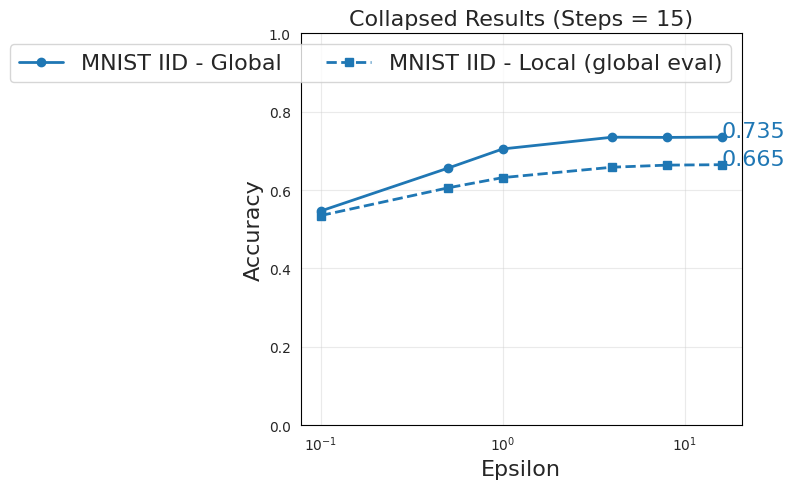

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor':'black'})

dataset_names = ['MNIST IID','MNIST NIID-5', 'MNIST NIID-2', 'MNIST Dirch-1', 'MNIST Dirch-5']
methods = ['global', 'pooled']

method_labels = {
    'global': 'Global',
    'pooled': 'Local (global eval)'
}

colors = sns.color_palette("tab10", len(dataset_names))

linestyle_map = {
    'global': '-',
    'pooled': '--'
}

marker_map = {
    'global': 'o',
    'pooled': 's'
}

NUM_STEPS = 15

plt.figure(figsize=(7, 5))

for d_idx, df in enumerate(all_results):

    df['e'] = df['e'].astype(float)

    df = df[df['num_personal_steps'] == NUM_STEPS]

    df_grouped = (
        df.groupby(['e', 'type'])['mean_perf']
        .mean()
        .reset_index()
    )

    for method in methods:

        df_m = df_grouped[df_grouped['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values('e')

        plt.plot(
            df_m['e'],
            df_m['mean_perf'],
            label=f"{dataset_names[d_idx]} - {method_labels[method]}",
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[d_idx],
            linewidth=2
        )

        # label final value
        x_last = df_m['e'].values[-1]
        y_last = df_m['mean_perf'].values[-1]

        plt.text(
            x_last,
            y_last,
            f"{y_last:.3f}",
            fontsize=16,
            color=colors[d_idx]
        )

plt.xscale('log')
plt.xlabel("Epsilon", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.title(f"Collapsed Results (Steps = {NUM_STEPS})", fontsize=16)
plt.ylim(0, 1)
plt.grid(True, alpha=0.4)

plt.legend(fontsize=16, ncol=2)
plt.tight_layout()
plt.show()

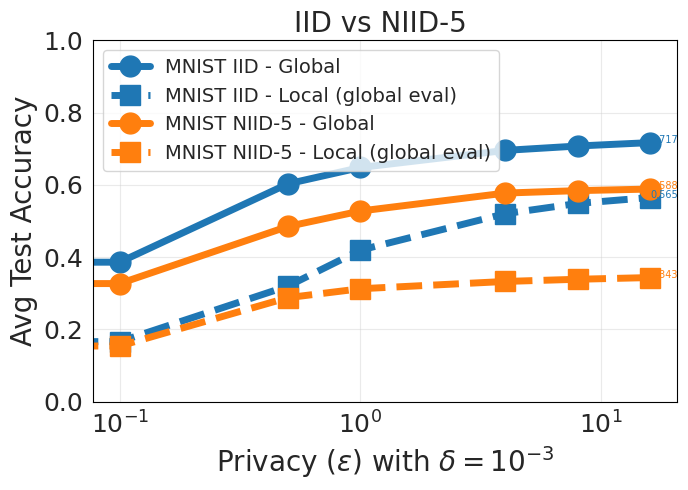

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor':'black'})

methods = ['global', 'pooled']

method_labels = {
    'global': 'Global',
    'pooled': 'Local (global eval)'
}

colors = sns.color_palette("tab10", 4)

linestyle_map = {
    'global': '-',
    'pooled': '--'
}

marker_map = {
    'global': 'o',
    'pooled': 's'
}

NUM_STEPS = 15

group1 = [0, 1]  # indices in all_results

plt.figure(figsize=(7, 5))

for d_idx in group1:
    df = all_results[d_idx]
    df['e'] = df['e'].astype(float)

    df = df[df['num_personal_steps'] == NUM_STEPS]

    df_grouped = (
        df.groupby(['e', 'type'])['mean_perf']
        .mean()
        .reset_index()
    )

    for method in methods:
        df_m = df_grouped[df_grouped['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values('e')

        plt.plot(
            df_m['e'],
            df_m['mean_perf'],
            label=f"{dataset_names[d_idx]} - {method_labels[method]}",
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[d_idx],
            linewidth = 5,
            markersize = 15
        )

        # final label
        x_last = df_m['e'].values[-1]
        y_last = df_m['mean_perf'].values[-1]

        plt.text(x_last, y_last, f"{y_last:.3f}", fontsize=7, color=colors[d_idx])

plt.xscale('log')
plt.tick_params(axis='both', labelsize=18)
plt.xlabel(r"Privacy ($\epsilon$) with $\delta = 10^{-3}$", fontsize=20)
plt.ylabel("Avg Test Accuracy", fontsize=20)
plt.title("IID vs NIID-5 ", fontsize=20)
plt.ylim(0, 1)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()